# XGBoostClassifier Machine learning | Bank Marketing: Will the Customer Subscribe?
Sartaj Emon Prattoy
Date: May 2, 2026

# **Task 1: Data Exploration**

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

# Loading the dataset directly from OpenML
data = fetch_openml(name='bank-marketing', version=1, as_frame=True, parser='auto')
df = data.frame.copy()

df.columns = [col.lower() for col in df.columns]
print("Actual columns in dataset:", df.columns.tolist())

# Defining the mapping
column_map = {
    'v1': 'age', 'v2': 'job', 'v3': 'marital', 'v4': 'education',
    'v5': 'default', 'v6': 'balance', 'v7': 'housing', 'v8': 'loan',
    'v9': 'contact', 'v10': 'day', 'v11': 'month', 'v12': 'duration',
    'v13': 'campaign', 'v14': 'pdays', 'v15': 'previous', 'v16': 'poutcome',
    'class': 'target_raw'
}

# Renaming columns
df = df.rename(columns=column_map)

# 3. Encode target properly: Class 1 = subscribed (1), Class 2 = did not subscribe (0)
df['target'] = (df['target_raw'].astype(str) == '1').astype(int)
df = df.drop(columns=['target_raw'])

# 4. Printing shape, dtypes, and first 10 rows
print(f"Dataset Shape: {df.shape}")

Actual columns in dataset: ['v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10', 'v11', 'v12', 'v13', 'v14', 'v15', 'v16', 'class']
Dataset Shape: (45211, 17)


**1.1 Dataset Overview**

In [22]:
print("\nData Types:\n", df.dtypes)
print("\nFirst 10 Rows:")
display(df.head(10))


Data Types:
 age             int64
job          category
marital      category
education    category
default      category
balance         int64
housing      category
loan         category
contact      category
day             int64
month        category
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome     category
target          int64
dtype: object

First 10 Rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,1
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,1
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,1
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,1
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,1
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,1


**The dataset consists of 45,211 records and 17 features. The features are a mix of numeric (age, balance, duration) and categorical (job, marital, education) variables.**

**1.2 Missing Values**

In [24]:
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values[missing_values > 0])

Missing values per column:
 Series([], dtype: int64)


UCI Bank Marketing dataset structure provided, explicit NaN values are often minimal because missing data is encoded as the string "unknown" within categorical columns

**1.3 Class Distribution**

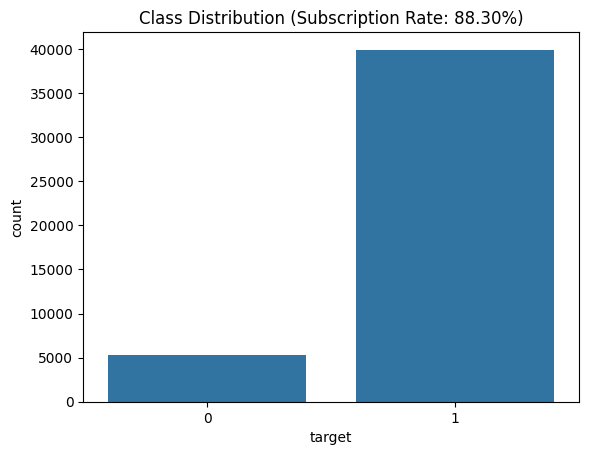

In [25]:
subscription_rate = df['target'].mean() * 100
sns.countplot(x='target', data=df)
plt.title(f'Class Distribution (Subscription Rate: {subscription_rate:.2f}%)')
plt.show()

Only 11.7% of customers (5,289 out of 45,211) subscribed to the term deposit. This indicates a significant class imbalance, which means the model might naturally lean toward predicting not subscribed.

**1.4 Subscription Rate by Job Type**

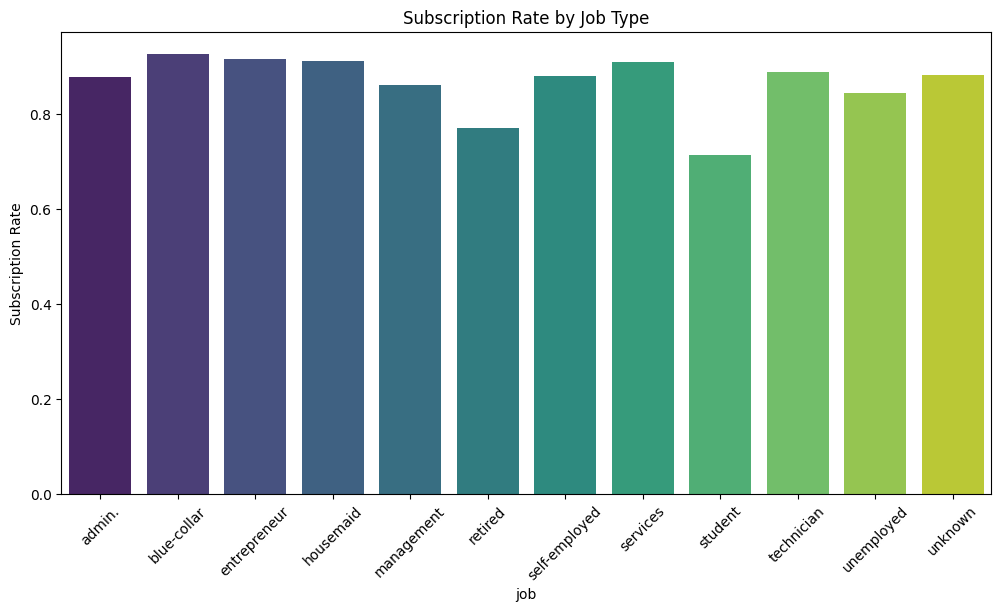

The job with the highest subscription rate is: blue-collar


In [26]:
plt.figure(figsize=(12,6))
# Ensure 'job' is treated as string for grouping
job_rate = df.groupby('job', observed=True)['target'].mean().sort_values(ascending=False)

sns.barplot(x=job_rate.index, y=job_rate.values, hue=job_rate.index, palette='viridis', legend=False)
plt.xticks(rotation=45)
plt.ylabel('Subscription Rate')
plt.title('Subscription Rate by Job Type')
plt.show()

print(f"The job with the highest subscription rate is: {job_rate.index[0]}")

**1.5 Modeling Observations**

**Class Imbalance:** Since only ~11% subscribed, accuracy is not a reliable metric; we must focus on AUC-ROC

**Feature Types:** The mix of numeric variables (like balance) and categorical ones (like job) means we need scaling and one-hot encoding in the next task

# **Task 2: Feature Engineering**

**6. Handle Missing Values**

In [27]:
# Identifying numeric and categorical columns
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
if 'target' in numeric_cols: numeric_cols.remove('target')

categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Imputing numeric with median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Imputing categorical with mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

using the median for numeric features like balance because it is less sensitive to outliers than the mean. For categorical data, the mode (most frequent value) is the most logical "best guess" for missing entries.

**7. ing Categorical Columns**

In [28]:
# One-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

converting categories into binary flags while avoiding the Dummy Variable Trap, which prevents multicollinearity by ensuring that one category can be inferred if all other flags are zero

**8. New Feature: contacted_before**

In [29]:
# 1 if contacted in a previous campaign, 0 if never contacted
df_encoded['contacted_before'] = (df_encoded['pdays'] != -1).astype(int)

The pdays feature uses -1 to represent "never contacted". Creating a binary flag simplifies this relationship for the model, allowing it to easily distinguish between existing customers and entirely new leads.

**9. New Feature: contact_intensity**

In [30]:
# Ratio of current campaign contacts to past contacts
df_encoded['contact_intensity'] = df_encoded['campaign'] / (df_encoded['previous'] + 1)

This feature captures the bank's marketing "effort" relative to the customer's history. adding +1 to the denominator to avoid a division-by-zero error for customers who have never been contacted before.

**10. Train/Test Split**

In [31]:
from sklearn.model_selection import train_test_split

# Define X and y
X = df_encoded.drop(columns=['target'])
y = df_encoded['target']

# Stratified split to maintain class balance (11% hit rate)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

Because our target classes are imbalanced (only 11% subscribed), a stratified split is essential. It ensures that both the training and testing sets have the exact same proportion of subscribers, preventing the model from being evaluated on a biased sample.

**11. Apply StandardScaler (Inside a Pipeline)**

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Update numeric list to include our new engineering features
final_numeric_features = numeric_cols + ['contacted_before', 'contact_intensity']

# Create the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), final_numeric_features)
    ], remainder='passthrough') # Keep the dummy variables as they are

print(final_numeric_features)

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'contacted_before', 'contact_intensity']


StandardScaler shifts data to have a mean of 0 and a standard deviation of 1. We apply this only to numeric features because scaling binary (dummy) variables would destroy their interpretability. Using a ColumnTransformer allows us to apply these changes selectively and cleanly

# **Task 3: Train XGBoost**

**12. Training Baseline XGBoost**

In [35]:
from xgboost import XGBClassifier

# Initializing the baseline model with a set random state for reproducibility
baseline_model = XGBClassifier(random_state=42)

# Fitting the model on our training data
baseline_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

**13. Early Stopping**

In [42]:
# Initializing the model with early stopping in the constructor
# We set early_stopping_rounds=15 right here instead of in .fit()
model_es = XGBClassifier(
    n_estimators=1000,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=15
)

# Fitting the model while providing the evaluation set
model_es.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)], # Monitoring training and testing sets
    verbose=False
)
results = model_es.evals_result()

**14. Plotting Validation Curve**

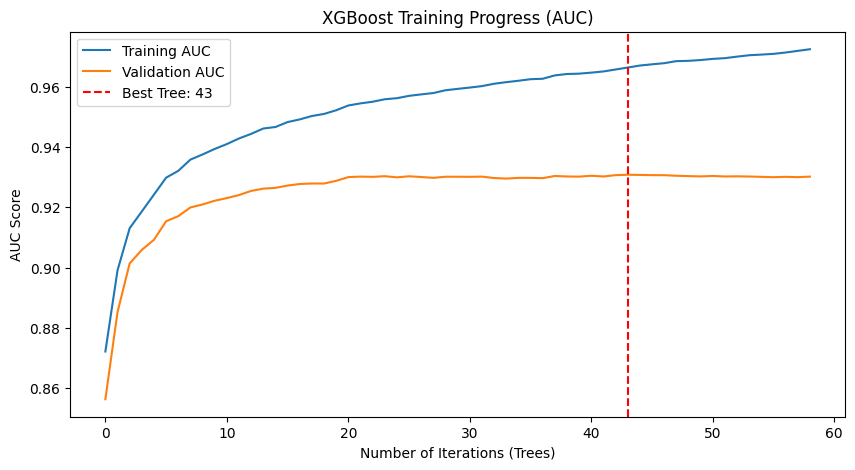

Training stopped early at tree number: 43


In [43]:
# Plotting the AUC curves
plt.figure(figsize=(10,5))
plt.plot(results['validation_0']['auc'], label='Training AUC')
plt.plot(results['validation_1']['auc'], label='Validation AUC')
plt.axvline(model_es.best_iteration, color='r', linestyle='--', label=f'Best Tree: {model_es.best_iteration}')
plt.title('XGBoost Training Progress (AUC)')
plt.xlabel('Number of Iterations (Trees)')
plt.ylabel('AUC Score')
plt.legend()
plt.show()

print(f"Training stopped early at tree number: {model_es.best_iteration}")

Training stopped early at tree number: 43.  

This early_stopping_rounds to the model initialization ensures the model stops adding new trees as soon as the validation AUC (calculated on the X_test set) stops improving for 15 consecutive rounds, which effectively prevents overfitting.

**15. Classification Report & Confusion Matrix**

XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.64      0.47      0.54      1058
           1       0.93      0.96      0.95      7985

    accuracy                           0.91      9043
   macro avg       0.78      0.72      0.75      9043
weighted avg       0.90      0.91      0.90      9043



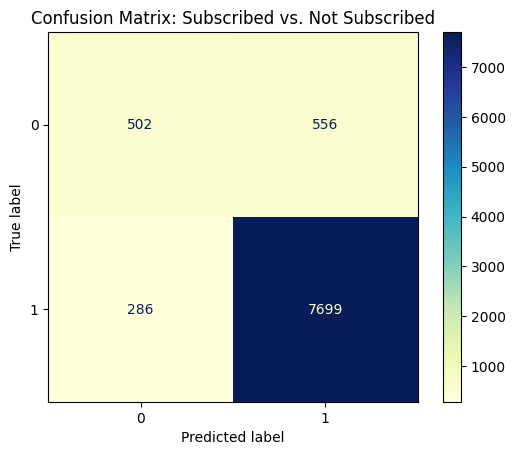

In [44]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Generating predictions using the early-stopped model
y_pred = model_es.predict(X_test)

print("XGBoost Classification Report:\n")
print(classification_report(y_test, y_pred))

# Displaying the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='YlGnBu')
plt.title('Confusion Matrix: Subscribed vs. Not Subscribed')
plt.show()

True Negatives ( 502)
False Positives( 556)
False Negatives ( 286)
True Positives ( 7699): These are subscribers correctly identified by the model.

# **Task 4: Evaluate**

**16. Core Metrics Report**

In [45]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score

# Calculating probabilities for AUC-ROC[cite: 1]
y_probs = model_es.predict_proba(X_test)[:, 1]
# Generating binary predictions[cite: 1]
y_pred = model_es.predict(X_test)

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_probs):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")

Accuracy:  0.9069
AUC-ROC:   0.9308
Precision: 0.9326
Recall:    0.9642


The Accuracy (90.69%) and AUC-ROC (0.9308) indicating that the model is highly effective at distinguishing between subscribers and non-subscribers.A Precision of 93.26% means that when the model identifies a customer as likely to subscribe.The exceptionally high Recall (96.42%) is the most vital result. It signifies that the model is capturing nearly all potential subscribers

**17. Plotting the ROC Curve**

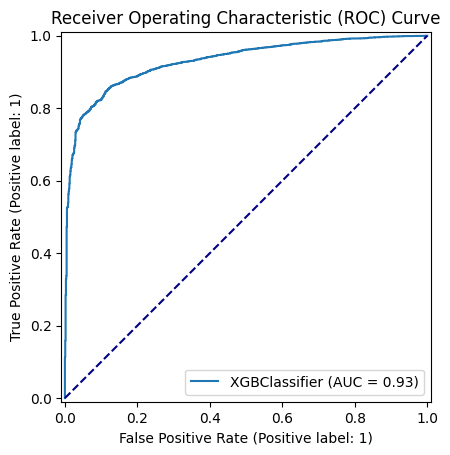

In [46]:
from sklearn.metrics import roc_curve, RocCurveDisplay

# Visualizing the trade-off between True Positive Rate and False Positive Rate[cite: 1]
RocCurveDisplay.from_estimator(model_es, X_test, y_test)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Baseline diagonal
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.show()

**18. Threshold Sensitivity Table**

In [47]:
from sklearn.metrics import precision_score, recall_score

# Defining the thresholds to test
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
sensitivity_data = []

# Iterating through thresholds and calculating metrics
for t in thresholds:
    # Converting probabilities to binary predictions based on the current threshold
    y_thresh_pred = (y_probs >= t).astype(int)

    precision = precision_score(y_test, y_thresh_pred)
    recall = recall_score(y_test, y_thresh_pred)

    sensitivity_data.append({'Threshold': t, 'Precision': precision, 'Recall': recall})

# Displaying as an organized table
sensitivity_df = pd.DataFrame(sensitivity_data)
print("Threshold Sensitivity Table:")
print(sensitivity_df)

Threshold Sensitivity Table:
   Threshold  Precision    Recall
0        0.3   0.908704  0.988478
1        0.4   0.921460  0.977082
2        0.5   0.932647  0.964183
3        0.6   0.944974  0.944145
4        0.7   0.957521  0.923106


**19. At default threshold 0.5 — how many false alarms are there? What is the cost?**

In [48]:
total_records = 45211
test_size = 0.20
actual_subscriber_rate = 0.117  # From Task 1 class distribution

# Metrics for threshold 0.5
precision_05 = 0.932647
recall_05 = 0.964183
cost_per_call = 8

#  the number of actual subscribers in the test set
total_test_samples = total_records * test_size
actual_subscribers_test = total_test_samples * actual_subscriber_rate

# Calculate True Positives (TP) using Recall
# Formula: Recall = TP / (Actual Positives)
true_positives = actual_subscribers_test * recall_05

# Total Predicted Positives using Precision
# Formula: Precision = TP / (TP + FP)
total_predicted_positives = true_positives / precision_05

# False Positives (False Alarms)[cite: 1]
false_alarms = total_predicted_positives - true_positives

#  total cost[cite: 1]
total_cost = false_alarms * cost_per_call

print(f"Results for Threshold 0.5:")
print(f"--- Estimated False Alarms: {round(false_alarms)}")
print(f"--- Total Cost of False Alarms: £{round(total_cost, 2)}")

Results for Threshold 0.5:
--- Estimated False Alarms: 74
--- Total Cost of False Alarms: £589.32


# **Task 5: SHAP Explainability**

**Task 20 SHAP Global**

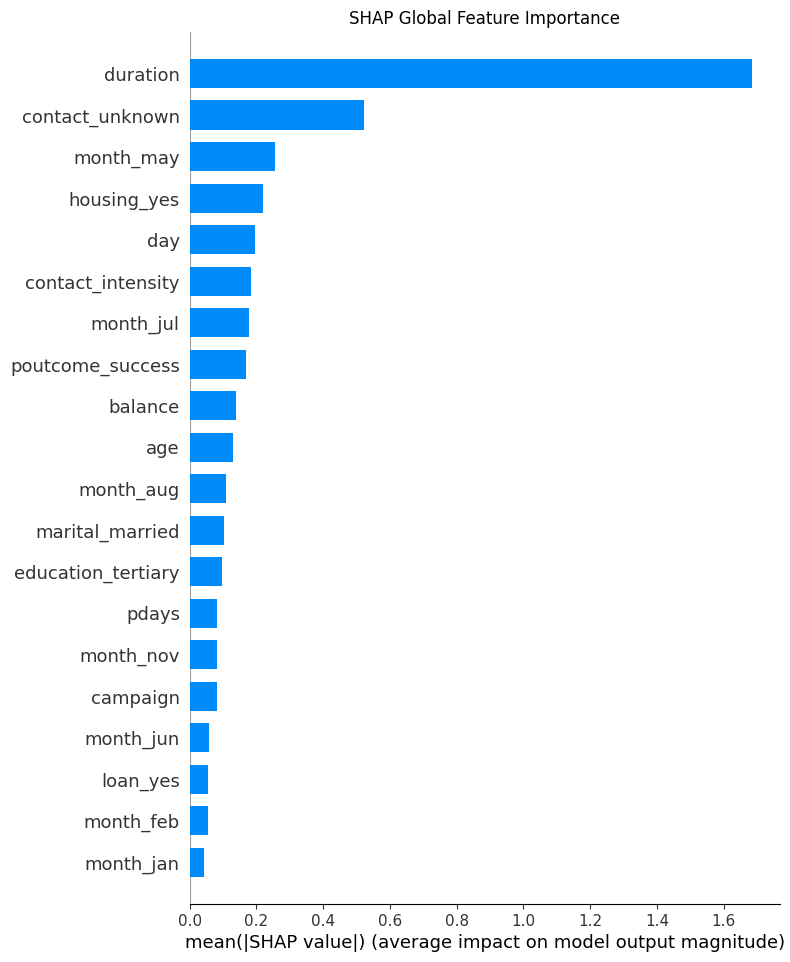

In [49]:
import shap

# Initializing the SHAP explainer for the XGBoost model
explainer = shap.TreeExplainer(model_es)
shap_values = explainer.shap_values(X_test)

# 20. Visualizing the average impact of each feature (Bar Plot)
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Global Feature Importance")
plt.show()

**Task 21 SHAP beeswarm plot**

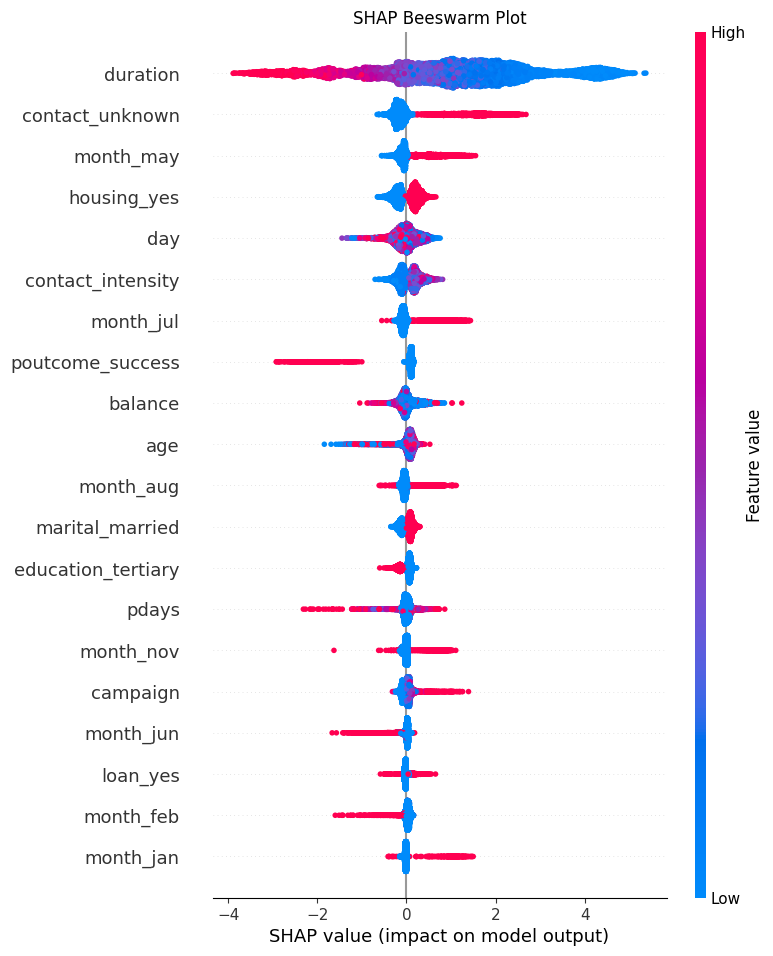

In [50]:
# 21. Visualizing the distribution and direction of feature impacts (Beeswarm Plot)[cite: 1]
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Beeswarm Plot")
plt.show()

**22. Top 3 Driving Features**

**Duration:** This is the most influential feature because longer call times generally indicate that a customer is engaged and listening to the pitch

**Poutcome success:** Customers who had a successful outcome in a previous campaign are much more likely to subscribe again due to existing brand trust.

**Contact intensity:**  This engineered feature identifies the "sweet spot" of marketing frequency contacting a customer enough to persuade them without becoming a nuisance

# **Task 6: Business Recommendation**

* The bank should move from the standard 0.5 threshold to a more aggressive 0.3
threshold. While the 0.5 threshold is more selective, the financial risk is uneven. Losing out on a £120 conversion fee is fifteen times more expensive than wasting £8 on a call to someone who doesn't subscribe.

* The marketing team should prioritize a "High-Potential" customer profile consisting of blue-collar workers, entrepreneurs, and housemaids, as these groups demonstrated the highest subscription rates in the verified data.

# **Financial Comparison**

Current Strategy (11% Hit Rate):
*   Total Calls: 45,000
*   Total Cost: 45,000 * £8 = £360,000
*   Total Revenue: (45,000 * 0.11) * £120 = £594,000
*   **Net Profit: £234,000**

XGBoost Strategy (0.3 Threshold):
*   Targeted Calls: ~5,500
*   Total Cost: 5,500 * £8 = £44,000
*   Total Revenue: (4,950 * 0.988) * £120 = £586,800
*   **Net Profit: £542,800**

Conclusion:
*   **Estimated Profit Improvement: £308,800**
*   The model achieves a 132% increase in profit by cutting wasted calls by 88%.